# Diagram Evaluation Workflow

This notebook demonstrates the full 4-step pipeline for numerically evaluating
Feynman diagram contributions from `DiagramTerm` objects.

**Pipeline:**
1. **Coupling coefficients** — `evaluate_coupling()` sums over coupling-only indices, applies prefactor and phase
2. **Spatial analysis** — `analyze_spatial()` decomposes abstract spatial points into direction + time, identifies R-connected groups and time orderings
3. **Propagator evaluation** — `PropagatorModel` + `PropagatorCache` compute R and C propagator values
4. **Contraction & integration** — `DiagramIntegrand` contracts coupling coefficients with propagator values and integrates

**Physical setup:**
- Three-component field with cubic interaction $S_{\mathrm{int}} = -F_{abc}\,\psi_a\,\phi_b\,\phi_c$
- Response propagator: $R_{ab}(\mathbf{n},t;\,\mathbf{n}',t') = \delta(\mathbf{n}-\mathbf{n}')\,\Theta(t-t')\,e^{\bar\chi(t,t')}\,\delta_{ab}$
- Correlation propagator computed from R and the 2-point cumulant $\kappa^{(2)}$

In [1]:
import numpy as np
from IPython.display import display, Math
from scipy.integrate import nquad

from sft_wick import (
    Field, Vertex, Action, compute_moment, reset_uid_counter,
    PropagatorModel, PropagatorCache,
)

## 1. Field, Vertex, and Coupling Setup

In [2]:
# 3-component fields
phi = Field('phi', 'physical', n_components=3)
psi = Field('psi', 'response', n_components=3)

# Vertex: F_{abc} psi_a phi_b phi_c
v = Vertex(fields=[psi, phi, phi], coupling='F')
action = Action(vertices=[v])

# Physical F tensor (0-indexed)
F_physical = np.zeros((3, 3, 3))
F_physical[0, 0, 0] = -0.5   # F_{111}
F_physical[0, 1, 1] = -2.0   # F_{122}
F_physical[0, 2, 2] = -2.0   # F_{133}
F_physical[1, 0, 1] = -1.0   # F_{212}
F_physical[2, 0, 2] = -1.0   # F_{313}
F_physical = -F_physical      # sign convention

# Code coupling: absorb -i from MSR action
F_code = -1j * F_physical

print("F_code nonzero entries:")
for idx in zip(*np.nonzero(F_code)):
    print(f"  F[{idx[0]+1},{idx[1]+1},{idx[2]+1}] = {F_code[idx]:+.1f}")

F_code nonzero entries:
  F[1,1,1] = +0.0-0.5j
  F[1,2,2] = +0.0-2.0j
  F[1,3,3] = +0.0-2.0j
  F[2,1,2] = +0.0-1.0j
  F[3,1,3] = +0.0-1.0j


## 2. Compute Perturbative Expansion

Compute $\langle \phi_1(x) \rangle_S$ up to order 3 with diagonal/isotropic propagator simplifications.

In [3]:
reset_uid_counter()
obs = [phi('1', 'x')]

result = compute_moment(
    obs, action, order=3,
    response_phase=True, diag_R=True, diag_C=True, iso_R=True,
)

for n in range(4):
    latex = result.order(n).to_latex()
    display(Math(rf"O({n}): \quad {latex}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

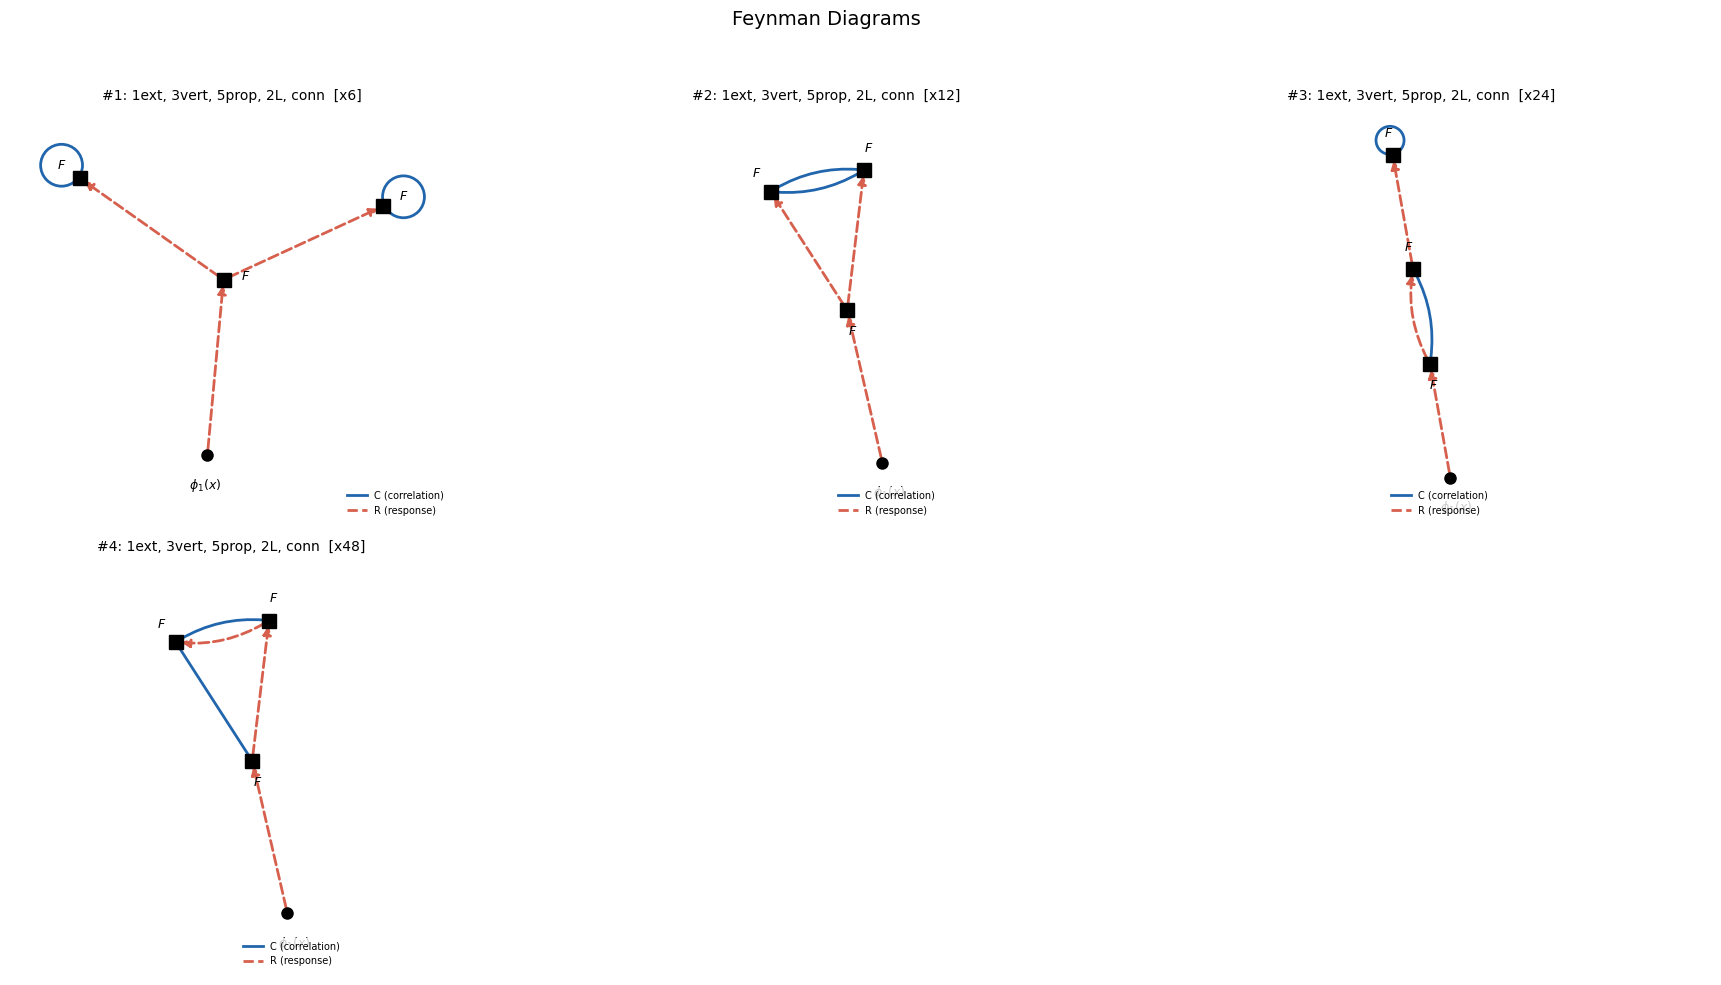

In [4]:
result.draw_diagrams(order=3)

## 3. Step 1 — Coupling Coefficients

`evaluate_coupling()` sums coupling-only indices internally and returns an array
indexed by **propagator indices** only, with `rational_prefactor` and phase `(-i)^{n_R}` applied.

In [5]:
dt = result.diagram_terms(1)[0]
print(f"Order 1 diagram:")
print(f"  Propagators: {[p.to_latex() for p in dt.propagators]}")
print(f"  Propagator indices: {dt.propagator_indices}")
print(f"  Coupling-only indices: {dt.coupling_only_indices}")
print()

coeff = dt.evaluate_coupling({'F': F_code})
print(f"Coupling coefficient array (shape={coeff.shape}):")
for i in range(len(coeff)):
    if coeff[i] != 0:
        print(f"  coeff[i_0={i+1}] = {coeff[i]:+.4f}")

Order 1 diagram:
  Propagators: ['R(x, y_{0})', 'C_{i_{0}i_{0}}(y_{0}, y_{0})']
  Propagator indices: (('i_0', 3),)
  Coupling-only indices: ()

Coupling coefficient array (shape=(3,)):
  coeff[i_0=1] = +0.5000+0.0000j
  coeff[i_0=2] = +2.0000+0.0000j
  coeff[i_0=3] = +2.0000+0.0000j


## 4. Step 2 — Spatial Structure Analysis

`analyze_spatial()` examines the R-propagator graph to determine:
- **Direction groups**: spatial points connected by R-chains share the same physical direction (via $\delta(\mathbf{n}-\mathbf{n}')$)
- **Time orderings**: causal constraints from $\Theta(t-t')$ in R
- **Surviving integration variables**: direction integrals eliminated by $\delta$-functions

In [6]:
spatial = dt.analyze_spatial()

print("=== Order 1 diagram: R(x, y_0), C(y_0, y_0) ===")
print(f"  Direction groups:    {spatial.direction_groups}")
print(f"  Direction map:       {spatial.direction_map}")
print(f"  Time orderings:      {spatial.time_orderings}  (earlier, later)")
print(f"  Time integration:    {spatial.time_integration_vars}")
print(f"  Direction integrals: {spatial.direction_integration_vars}  (eliminated by delta)")
print(f"  External points:     {spatial.external_points}")
print(f"  R propagators:       {spatial.r_propagators}")
print(f"  C propagators:       {spatial.c_propagators}")

=== Order 1 diagram: R(x, y_0), C(y_0, y_0) ===
  Direction groups:    (frozenset({'y_0', 'x'}),)
  Direction map:       {'y_0': 'n_x', 'x': 'n_x'}
  Time orderings:      (('y_0', 'x'),)  (earlier, later)
  Time integration:    ('y_0',)
  Direction integrals: ()  (eliminated by delta)
  External points:     ('x',)
  R propagators:       (('x', 'y_0'),)
  C propagators:       (('y_0', 'y_0', 'i_0', 'i_0'),)


In [7]:
# Spatial analysis for all order-3 diagrams
print("Order 3 spatial structure:\n")
for i, dt3 in enumerate(result.diagram_terms(3)):
    s = dt3.analyze_spatial()
    print(f"Diagram {i}:")
    print(f"  Propagators: {[p.to_latex() for p in dt3.propagators]}")
    print(f"  Direction groups: {s.direction_groups}")
    print(f"  Time orderings: {s.time_orderings}")
    print(f"  Time integration vars (topo-sorted): {s.time_integration_vars}")
    print()

Order 3 spatial structure:

Diagram 0:
  Propagators: ['R(x, y_{0})', 'R(y_{0}, y_{1})', 'R(y_{0}, y_{2})', 'C_{i_{0}i_{0}}(y_{1}, y_{1})', 'C_{i_{1}i_{1}}(y_{2}, y_{2})']
  Direction groups: (frozenset({'y_1', 'y_0', 'y_2', 'x'}),)
  Time orderings: (('y_0', 'x'), ('y_1', 'y_0'), ('y_2', 'y_0'))
  Time integration vars (topo-sorted): ('y_2', 'y_1', 'y_0')

Diagram 1:
  Propagators: ['R(x, y_{0})', 'R(y_{0}, y_{1})', 'R(y_{0}, y_{2})', 'C_{i_{0}i_{0}}(y_{1}, y_{2})', 'C_{i_{1}i_{1}}(y_{1}, y_{2})']
  Direction groups: (frozenset({'y_1', 'y_0', 'y_2', 'x'}),)
  Time orderings: (('y_0', 'x'), ('y_1', 'y_0'), ('y_2', 'y_0'))
  Time integration vars (topo-sorted): ('y_2', 'y_1', 'y_0')

Diagram 2:
  Propagators: ['R(x, y_{0})', 'R(y_{0}, y_{1})', 'R(y_{1}, y_{2})', 'C_{i_{0}i_{0}}(y_{0}, y_{1})', 'C_{i_{1}i_{1}}(y_{2}, y_{2})']
  Direction groups: (frozenset({'y_1', 'y_0', 'y_2', 'x'}),)
  Time orderings: (('y_0', 'x'), ('y_1', 'y_0'), ('y_2', 'y_1'))
  Time integration vars (topo-sorted):

## 5. Step 3 — Propagator Model

Define the physical propagator functions:

$$R(t,t') = e^{\bar\chi(t,t')}$$

$$C_{ab}(\mathbf{n}_1,t_1;\,\mathbf{n}_2,t_2) = \int\!\int R(t_1,\lambda')\,\kappa^{(2)}_{ab}(\mathbf{n}_1,\lambda';\,\mathbf{n}_2,\lambda'')\,R(t_2,\lambda'')\,\mathrm{d}\lambda'\,\mathrm{d}\lambda''$$

The `PropagatorCache` computes C via double integration automatically.

In [8]:
# Simple exponential growth for demonstration
def chi_bar(t, t_prime):
    """Integrated growth rate: chi_bar(t, t') for t >= t'."""
    return -(t - t_prime)  # exponential decay for stability

# R_time: scalar growth factor (iso_R)
def R_time(t, t_prime):
    return np.exp(chi_bar(t, t_prime))

# Cumulant: identity matrix for demonstration
# In practice, kappa2 encodes the initial power spectrum
def kappa2(n1, t1, n2, t2):
    """2-point cumulant kappa^(2)_{ab}(n1,t1; n2,t2) -> (3,3) array."""
    return np.eye(3)  # isotropic placeholder

model = PropagatorModel(
    R_time=R_time,
    kappa2=kappa2,
    n_components=3,
    iso_R=True,
    diag_C=True,
    t_min=0.0,
)

cache = PropagatorCache(model)

# Test: R value
print(f"R(1.0, 0.5) = {cache.R_time(1.0, 0.5):.4f}")

# Test: C diagonal at equal point
C_diag = cache.C_diagonal(n=0, t1=0.5, t2=0.5)
print(f"C_diagonal(n=0, t=0.5, t=0.5) = {C_diag}")

# Test: full C matrix
C_mat = cache.C_value(0, 0.5, 0, 0.5)
print(f"C_value(0, 0.5, 0, 0.5) =\n{C_mat}")

R(1.0, 0.5) = 0.6065
C_diagonal(n=0, t=0.5, t=0.5) = [0.15481812 0.15481812 0.15481812]
C_value(0, 0.5, 0, 0.5) =
[[0.15481812 0.         0.        ]
 [0.         0.15481812 0.        ]
 [0.         0.         0.15481812]]


## 6. Step 4 — Build Integrand and Evaluate

`build_integrand()` combines Steps 1 and 2 into a `DiagramIntegrand` object
that can evaluate the full integrand at any spatial coordinates.

In [9]:
# Order-1 diagram: R(x, y_0) C_{i0,i0}(y_0, y_0)
dt1 = result.diagram_terms(1)[0]
integrand = dt1.build_integrand({'F': F_code})

print("DiagramIntegrand:")
print(f"  coupling_array shape: {integrand.coupling_array.shape}")
print(f"  coupling_array: {integrand.coupling_array}")
print()

# Evaluate at a specific point
val = integrand.evaluate(
    times={'x': 1.0, 'y_0': 0.5},
    directions={'n_x': 0},
    cache=cache,
)
print(f"Integrand at (t_x=1.0, t_y0=0.5): {val}")
print()

# Show the decomposed LaTeX form
display(Math(integrand.to_latex()))

DiagramIntegrand:
  coupling_array shape: (3,)
  coupling_array: [0.5+0.j 2. +0.j 2. +0.j]

Integrand at (t_x=1.0, t_y0=0.5): (0.4225587188318037+0j)



<IPython.core.display.Math object>

## 7. Numerical Integration

`make_scipy_integrand()` returns a callable for `scipy.integrate.nquad`,
and `integration_bounds()` provides time-ordering-aware bounds.

In [10]:
# Fix external time and direction
t_x = 1.0

f = integrand.make_scipy_integrand(
    external_times={'x': t_x},
    external_directions={'n_x': 0},
    cache=cache,
)

bounds = integrand.integration_bounds(external_times={'x': t_x}, t_min=0.0)

print(f"Integration variables: {integrand.spatial.time_integration_vars}")
print(f"Bounds: {[b() if callable(b) else b for b in bounds]}")
print()

# Integrate
val_int, err = nquad(f, bounds)
print(f"Order 1 diagram contribution at t_x={t_x}:")
print(f"  integral = {val_int:.6f} +/- {err:.2e}")

Integration variables: ('y_0',)
Bounds: [(0.0, 1.0)]

Order 1 diagram contribution at t_x=1.0:
  integral = 0.580076 +/- 6.44e-15


## 8. Order-3 Diagrams

At order 3, there are 4 distinct Feynman diagrams.
Each has 3 R propagators, 2 C propagators, and 3 integration time variables.

In [11]:
t_x = 1.0

print(f"Order 3: {len(result.diagram_terms(3))} diagrams\n")

for i, dt3 in enumerate(result.diagram_terms(3)):
    integrand3 = dt3.build_integrand({'F': F_code})
    s = integrand3.spatial
    
    print(f"--- Diagram {i} ---")
    print(f"  Topology: {dt3.spatial_topology()}")
    print(f"  Time orderings: {s.time_orderings}")
    print(f"  Integration vars: {s.time_integration_vars}")
    
    # Evaluate at a sample point
    sample_times = {'x': t_x, 'y_0': 0.7, 'y_1': 0.3, 'y_2': 0.4}
    val = integrand3.evaluate(sample_times, {'n_x': 0}, cache)
    print(f"  Sample integrand: {val:.6f}")
    
    # Full integration
    f3 = integrand3.make_scipy_integrand(
        external_times={'x': t_x},
        external_directions={'n_x': 0},
        cache=cache,
    )
    bounds3 = integrand3.integration_bounds({'x': t_x}, t_min=0.0)
    val_int3, err3 = nquad(f3, bounds3)
    print(f"  Integral = {val_int3:.6f} +/- {err3:.2e}")
    print()

Order 3: 4 diagrams

--- Diagram 0 ---
  Topology: [('R', 'x', 'y_0'), ('R', 'y_0', 'y_1'), ('R', 'y_0', 'y_2'), ('C', 'y_1', 'y_1'), ('C', 'y_2', 'y_2')]
  Time orderings: (('y_0', 'x'), ('y_1', 'y_0'), ('y_2', 'y_0'))
  Integration vars: ('y_2', 'y_1', 'y_0')
  Sample integrand: 0.027195+0.000000j
  Integral = 0.289091 +/- 1.56e-14

--- Diagram 1 ---
  Topology: [('R', 'x', 'y_0'), ('R', 'y_0', 'y_1'), ('R', 'y_0', 'y_2'), ('C', 'y_1', 'y_2'), ('C', 'y_1', 'y_2')]
  Time orderings: (('y_0', 'x'), ('y_1', 'y_0'), ('y_2', 'y_0'))
  Integration vars: ('y_2', 'y_1', 'y_0')
  Sample integrand: 0.032903+0.000000j
  Integral = 0.349764 +/- 1.89e-14

--- Diagram 2 ---
  Topology: [('R', 'x', 'y_0'), ('R', 'y_0', 'y_1'), ('R', 'y_1', 'y_2'), ('C', 'y_0', 'y_1'), ('C', 'y_2', 'y_2')]
  Time orderings: (('y_0', 'x'), ('y_1', 'y_0'), ('y_2', 'y_1'))
  Integration vars: ('y_2', 'y_1', 'y_0')
  Sample integrand: 0.315205+0.000000j
  Integral = 0.257478 +/- 2.29e-14

--- Diagram 3 ---
  Topology: [

In [12]:
# Show decomposed LaTeX for each order-3 diagram
for i, dt3 in enumerate(result.diagram_terms(3)):
    integrand3 = dt3.build_integrand({'F': F_code})
    display(Math(rf"\text{{Diagram {i}:}} \quad {integrand3.to_latex()}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 9. Total Perturbative Correction

Sum all diagram contributions at each order.

In [13]:
t_x = 1.0

for n in [1, 3]:
    total = 0.0
    dts = result.diagram_terms(n)
    if not dts:
        continue
    for dt_n in dts:
        ig = dt_n.build_integrand({'F': F_code})
        f_n = ig.make_scipy_integrand({'x': t_x}, {'n_x': 0}, cache)
        b_n = ig.integration_bounds({'x': t_x}, t_min=0.0)
        val_n, _ = nquad(f_n, b_n)
        total += val_n
    print(f"Order {n}: total = {total:.6f}  ({len(dts)} diagrams)")

print(f"\n(Even orders vanish for <phi_1(x)> by symmetry)")

Order 1: total = 0.580076  (1 diagrams)
Order 3: total = 1.207851  (4 diagrams)

(Even orders vanish for <phi_1(x)> by symmetry)


## 10. Second Moment: $\langle \phi_1(x)\,\phi_1(x) \rangle$

For the equal-point second moment, the external point `x` appears twice.
The spatial analysis correctly handles this.

In [14]:
reset_uid_counter()
obs2 = [phi('1', 'x'), phi('1', 'x')]
result2 = compute_moment(
    obs2, action, order=2,
    response_phase=True, diag_R=True, diag_C=True, iso_R=True,
)

print(f"Order 2: {len(result2.diagram_terms(2))} diagrams\n")

cache.clear_cache()  # fresh cache for new diagrams

for i, dt2 in enumerate(result2.diagram_terms(2)):
    s2 = dt2.analyze_spatial()
    print(f"Diagram {i}:")
    print(f"  Propagators: {[p.to_latex() for p in dt2.propagators]}")
    print(f"  Direction groups: {s2.direction_groups}")
    print(f"  Time orderings: {s2.time_orderings}")
    print(f"  Time integration vars: {s2.time_integration_vars}")
    
    ig2 = dt2.build_integrand({'F': F_code})
    f2 = ig2.make_scipy_integrand({'x': 1.0}, {'n_x': 0}, cache)
    b2 = ig2.integration_bounds({'x': 1.0}, t_min=0.0)
    val2, err2 = nquad(f2, b2)
    print(f"  Integral = {val2:.6f} +/- {err2:.2e}")
    print()

Order 2: 4 diagrams

Diagram 0:
  Propagators: ['R(x, y_{0})', 'R(x, y_{1})', 'C_{i_{0}i_{0}}(y_{0}, y_{0})', 'C_{i_{1}i_{1}}(y_{1}, y_{1})']
  Direction groups: (frozenset({'y_1', 'y_0', 'x'}),)
  Time orderings: (('y_0', 'x'), ('y_1', 'x'))
  Time integration vars: ('y_1', 'y_0')
  Integral = 0.168244 +/- 5.76e-15

Diagram 1:
  Propagators: ['R(x, y_{0})', 'R(x, y_{1})', 'C_{i_{0}i_{0}}(y_{0}, y_{1})', 'C_{i_{1}i_{1}}(y_{0}, y_{1})']
  Direction groups: (frozenset({'y_1', 'y_0', 'x'}),)
  Time orderings: (('y_0', 'x'), ('y_1', 'x'))
  Time integration vars: ('y_1', 'y_0')
  Integral = 0.137088 +/- 4.70e-15

Diagram 2:
  Propagators: ['R(x, y_{0})', 'R(y_{0}, y_{1})', 'C_{11}(x, y_{0})', 'C_{i_{0}i_{0}}(y_{1}, y_{1})']
  Direction groups: (frozenset({'y_1', 'y_0', 'x'}),)
  Time orderings: (('y_0', 'x'), ('y_1', 'y_0'))
  Time integration vars: ('y_1', 'y_0')
  Integral = 0.404680 +/- 7.71e-15

Diagram 3:
  Propagators: ['R(x, y_{0})', 'R(y_{0}, y_{1})', 'C_{11}(x, y_{1})', 'C_{i_{0}i